<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week6/abalone_DL_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

In [15]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week6/abalone.csv'
df = pd.read_csv(path)
df

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...,...
4172,4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


# 0. Data 검사 단계

- 결측치 확인
- 이상치 확인
- 노이즈 제거

In [16]:
# 결측치 확인
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [17]:
# 필요없는 Feature 제거
# id는 노이즈일 확률이 높으니 제거
df = df.drop('id', axis=1)

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64
Axes(0.125,0.11;0.775x0.77)


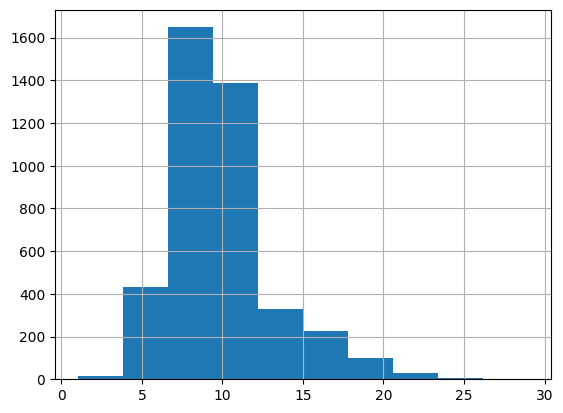

In [18]:
y = df['Rings']
print(y.describe())
print(y.hist())

In [19]:
X = df.drop('Rings', axis=1)
X.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055


In [20]:
# 문자열이 들어있는 Sex 열 -> One-Hot Encoding하기 (문자열 삭제)
# pandas의 get_dummies()를 이용해 One-Hot Encoding을 진행한다.
X = pd.get_dummies(X, columns=['Sex'], drop_first=True, dtype=int)
X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,1,0


# 1. 데이터 형태 변환 + 데이터 분할 + Scaling

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = X.values
y = y.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(3341, 9) (836, 9)
(3341,) (836,)


# 2. 딥러닝 모델 생성, 학습, 평가

In [22]:
import tensorflow as tf

layers = tf.keras.layers
models = tf.keras.models

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1],)), # 입력층 현재 30개의 열을 입력
    layers.Dense(128, activation='relu'), # 은닉층
    layers.Dropout(0.3), # Drop out
    layers.Dense(64, activation='relu'), #은닉층
    layers.Dense(1) #출력 1 Regression이므로 activation이 존재하지 않음
])

model.compile(
    optimizer='adam',
    loss='mse', # Regression이므로 loss function이 mse
    metrics=['mae', 'mse'] # Regression이므로 metrics가 mae(평균 절대 오차), mse이다.
)

# 과잉적합을 막기 위한 코드라고 함.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
)

# 이건 이번에 챗지피티한테 물어보니까 Optimizer(경사하강법)의 학습률을 줄이는 용도라고 한다!!!
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr], # callback으로 early_stopping()과 reduce_lr()를 넣어줌
    verbose=1
)

Epoch 1/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 32.9824 - mae: 4.3319 - mse: 32.9824 - val_loss: 7.3896 - val_mae: 1.8743 - val_mse: 7.3896 - learning_rate: 0.0010
Epoch 2/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9271 - mae: 1.8470 - mse: 7.9271 - val_loss: 5.5074 - val_mae: 1.6791 - val_mse: 5.5074 - learning_rate: 0.0010
Epoch 3/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4344 - mae: 1.8274 - mse: 7.4344 - val_loss: 5.2715 - val_mae: 1.6887 - val_mse: 5.2715 - learning_rate: 0.0010
Epoch 4/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6245 - mae: 1.7841 - mse: 6.6245 - val_loss: 5.3077 - val_mae: 1.6953 - val_mse: 5.3077 - learning_rate: 0.0010
Epoch 5/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.8460 - mae: 1.7539 - mse: 5.8460 - val_loss: 5.2775 - val_mae: 1.6961 - val_mse: 5.2775 - learning_rate: 0.0010
Epoch 6/100
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.7664 - mae: 1.7048 - mse: 5.7664 - val_loss: 4.9708 - val_ma

# 3. 예측 및 평가

In [23]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

y_pred = y_pred.flatten()
y_test = y_test.flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse) # Root MSE
print("MAE :", mae)
print("R2  :", r2) # 결정계수(coefficient of determination)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
MSE : 4.452339172363281
RMSE: 2.110056675154315
MAE : 1.4626200199127197
R2  : 0.5900357365608215


# 4. 학습 과정 시각화

In [24]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(loss) + 1)

## 손실 그래프

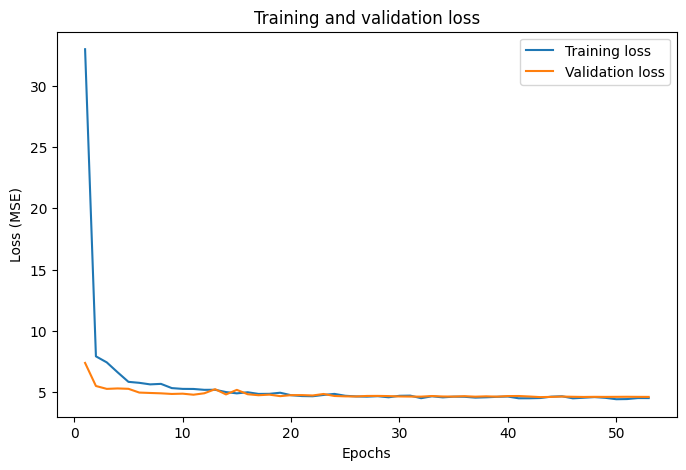

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

## MAE 그래프

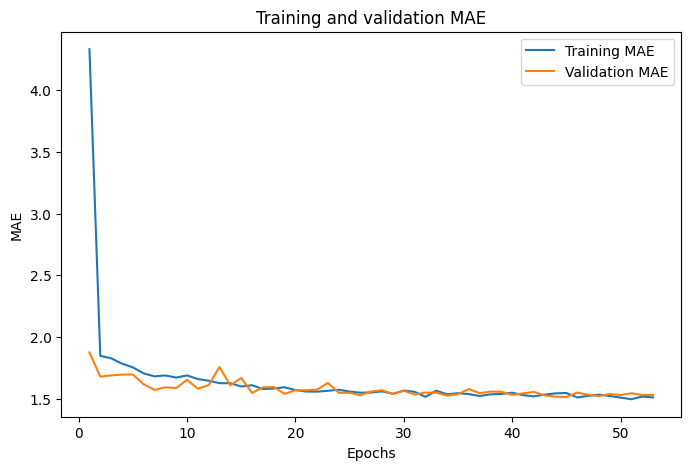

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.title('Training and validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()